# Safe Drinking Water Quality Screening
### ITA0604 – Machine Learning Assignment
# Name: K.Vamsi Kumar Reddy
# Reg No:192312670L

**Methods:** Candidate Elimination / Version Space + Decision Tree  
**Dataset:** 150 synthetic, non-sensitive records  
**Purpose:** Educational screening prototype only — not a substitute for certified laboratory testing.

In [ ]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)

np.random.seed(42)
print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Cell 2 — Generate the 150-record synthetic dataset
n = 150

pH_band = np.random.choice(
    ["Acidic", "Neutral", "Slightly Alkaline", "Alkaline"], n
)
turbidity = np.random.choice(["Low", "Medium", "High"], n)
tds_band = np.random.choice(["Low", "Normal", "High"], n)
chlorine = np.random.choice(["Low", "Adequate", "High"], n)
microbial = np.random.choice(["Absent", "Present"], n)
source = np.random.choice(
    ["Groundwater", "Surface", "Rainwater", "Municipal"], n
)

labels = []
for i in range(n):
    risk = 0
    if microbial[i] == "Present":
        risk += 3
    if turbidity[i] == "High":
        risk += 2
    elif turbidity[i] == "Medium":
        risk += 1
    if tds_band[i] == "High":
        risk += 1
    if chlorine[i] == "Low":
        risk += 1
    if pH_band[i] in ["Acidic", "Alkaline"]:
        risk += 1

    labels.append("Needs Treatment" if risk >= 3 else "Safe for Use")

df = pd.DataFrame({
    "pH_Band": pH_band,
    "Turbidity": turbidity,
    "TDS_Band": tds_band,
    "Chlorine": chlorine,
    "Microbial": microbial,
    "Source": source,
    "Class": labels
})

df.to_csv("water_quality_dataset.csv", index=False)

print("Dataset created successfully.")
print("Shape:", df.shape)
print("\nClass distribution:")
print(df["Class"].value_counts())

Dataset created successfully.
Shape: (150, 7)

Class distribution:
Class
Needs Treatment    107
Safe for Use        43
Name: count, dtype: int64


In [ ]:
# Cell 3 — Inspect the dataset
display(df.head(10))
print("\nDataset information:")
print("Records:", len(df))
print("Input attributes:", len(df.columns) - 1)
print("Target:", "Class")
print("\nMissing values:")
print(df.isnull().sum())

,pH_Band,Turbidity,TDS_Band,Chlorine,Microbial,Source,Class
0,Slightly Alkaline,High,Low,Adequate,Absent,Groundwater,Safe for Use
1,Alkaline,High,High,High,Present,Rainwater,Needs Treatment
2,Acidic,Low,Normal,Low,Present,Groundwater,Needs Treatment
3,Slightly Alkaline,High,Low,Adequate,Absent,Rainwater,Safe for Use
4,Slightly Alkaline,Low,High,High,Absent,Groundwater,Safe for Use
5,Alkaline,Medium,Low,Adequate,Present,Municipal,Needs Treatment
6,Acidic,High,Low,Low,Present,Surface,Needs Treatment
7,Acidic,Medium,Normal,Adequate,Absent,Groundwater,Safe for Use
8,Slightly Alkaline,Low,High,Adequate,Absent,Rainwater,Safe for Use
9,Neutral,High,High,Adequate,Absent,Municipal,Needs Treatment



Dataset information:
Records: 150
Input attributes: 6
Target: Class

Missing values:
pH_Band      0
Turbidity    0
TDS_Band     0
Chlorine     0
Microbial    0
Source       0
Class        0
dtype: int64


## Candidate Elimination / Version Space

Hypothesis representation:

`<pH_Band, Turbidity, TDS_Band, Chlorine, Microbial, Source>`

- `?` = any value
- `Ø` = most specific / no value initially
- `+` = positive example (Safe for Use)
- `-` = negative example (Needs Treatment)

In [ ]:
# Cell 4 — Manually selected Candidate Elimination examples
attributes = [
    "pH_Band", "Turbidity", "TDS_Band",
    "Chlorine", "Microbial", "Source"
]

ce_data = pd.DataFrame([
    ["Neutral", "Low", "Normal", "Adequate", "Absent", "Groundwater", "+"],
    ["Neutral", "High", "Normal", "Adequate", "Absent", "Groundwater", "-"],
    ["Neutral", "Low", "Normal", "Adequate", "Absent", "Surface", "+"],
    ["Neutral", "Low", "High", "Adequate", "Absent", "Surface", "-"],
    ["Neutral", "Low", "Normal", "Adequate", "Absent", "Surface", "+"],
    ["Neutral", "Low", "Normal", "Low", "Absent", "Surface", "-"],
    ["Slightly Alkaline", "Low", "Normal", "Adequate", "Absent", "Surface", "+"],
    ["Alkaline", "Low", "Normal", "Adequate", "Present", "Surface", "-"],
    ["Neutral", "Low", "Normal", "High", "Absent", "Municipal", "+"],
    ["Acidic", "High", "High", "Low", "Present", "Surface", "-"]
], columns=attributes + ["Class"])

display(ce_data)

,pH_Band,Turbidity,TDS_Band,Chlorine,Microbial,Source,Class
0,Neutral,Low,Normal,Adequate,Absent,Groundwater,+
1,Neutral,High,Normal,Adequate,Absent,Groundwater,-
2,Neutral,Low,Normal,Adequate,Absent,Surface,+
3,Neutral,Low,High,Adequate,Absent,Surface,-
4,Neutral,Low,Normal,Adequate,Absent,Surface,+
5,Neutral,Low,Normal,Low,Absent,Surface,-
6,Slightly Alkaline,Low,Normal,Adequate,Absent,Surface,+
7,Alkaline,Low,Normal,Adequate,Present,Surface,-
8,Neutral,Low,Normal,High,Absent,Municipal,+
9,Acidic,High,High,Low,Present,Surface,-


In [ ]:
# Cell 5 — Candidate Elimination implementation
def covers(h, example):
    return all(x == "?" or x == e for x, e in zip(h, example))

def more_general_or_equal(h1, h2):
    for a, b in zip(h1, h2):
        if a == "?":
            continue
        if a == "Ø":
            if b != "Ø":
                return False
        elif a != b:
            return False
    return True

def minimal_generalization(s, example):
    new_s = s.copy()
    for i in range(len(s)):
        if s[i] == "Ø":
            new_s[i] = example[i]
        elif s[i] != example[i]:
            new_s[i] = "?"
    return new_s

def minimal_specializations(g, example, domains):
    result = []
    for i in range(len(g)):
        if g[i] == "?":
            for value in domains[i]:
                if value != example[i]:
                    h = g.copy()
                    h[i] = value
                    result.append(h)
    return result

domains = [sorted(ce_data[a].unique()) for a in attributes]
S = ["Ø"] * len(attributes)
G = [["?"] * len(attributes)]

history = []

for index, row in ce_data.iterrows():
    example = row[attributes].tolist()
    label = row["Class"]

    if label == "+":
        G = [g for g in G if covers(g, example)]
        if not covers(S, example):
            S = minimal_generalization(S, example)
        G = [g for g in G if more_general_or_equal(g, S)]

    else:
        if covers(S, example):
            new_G = []
            for g in G:
                if covers(g, example):
                    for h in minimal_specializations(g, example, domains):
                        if more_general_or_equal(h, S):
                            new_G.append(h)
                else:
                    new_G.append(g)
            G = new_G

    history.append({
        "Example": f"E{index+1}",
        "Class": label,
        "S Boundary": str(S),
        "G Boundary": str(G)
    })

history_df = pd.DataFrame(history)

print("Candidate Elimination boundary updates:")
display(history_df)

print("\nFinal Specific Boundary (S):")
print(S)

print("\nFinal General Boundary (G):")
for g in G:
    print(g)

Candidate Elimination boundary updates:


,Example,Class,S Boundary,G Boundary
0,E1,+,"['Neutral', 'Low', 'Normal', 'Adequate', 'Abse...","[['?', '?', '?', '?', '?', '?']]"
1,E2,-,"['Neutral', 'Low', 'Normal', 'Adequate', 'Abse...","[['?', '?', '?', '?', '?', '?']]"
2,E3,+,"['Neutral', 'Low', 'Normal', 'Adequate', 'Abse...","[['?', '?', '?', '?', '?', '?']]"
3,E4,-,"['Neutral', 'Low', 'Normal', 'Adequate', 'Abse...","[['?', '?', '?', '?', '?', '?']]"
4,E5,+,"['Neutral', 'Low', 'Normal', 'Adequate', 'Abse...","[['?', '?', '?', '?', '?', '?']]"
5,E6,-,"['Neutral', 'Low', 'Normal', 'Adequate', 'Abse...","[['?', '?', '?', '?', '?', '?']]"
6,E7,+,"['?', 'Low', 'Normal', 'Adequate', 'Absent', '?']","[['?', '?', '?', '?', '?', '?']]"
7,E8,-,"['?', 'Low', 'Normal', 'Adequate', 'Absent', '?']","[['?', '?', '?', '?', '?', '?']]"
8,E9,+,"['?', 'Low', 'Normal', '?', 'Absent', '?']","[['?', '?', '?', '?', '?', '?']]"
9,E10,-,"['?', 'Low', 'Normal', '?', 'Absent', '?']","[['?', '?', '?', '?', '?', '?']]"



Final Specific Boundary (S):
['?', 'Low', 'Normal', '?', 'Absent', '?']

Final General Boundary (G):
['?', '?', '?', '?', '?', '?']


## Entropy and Information Gain

\[
H(S)=-\sum p_i\log_2(p_i)
\]

\[
IG(S,A)=H(S)-\sum_v\frac{|S_v|}{|S|}H(S_v)
\]

In [ ]:
# Cell 6 — Entropy and Information Gain
def entropy(series):
    probabilities = series.value_counts(normalize=True)
    return -sum(p * log2(p) for p in probabilities if p > 0)

def information_gain(data, attribute, target="Class"):
    parent = entropy(data[target])
    weighted = 0
    for _, subset in data.groupby(attribute):
        weighted += (len(subset) / len(data)) * entropy(subset[target])
    return parent - weighted

parent_entropy = entropy(ce_data["Class"])
ig_results = {
    attribute: information_gain(ce_data, attribute)
    for attribute in attributes
}
best_attribute = max(ig_results, key=ig_results.get)

print(f"Parent entropy: {parent_entropy:.4f}")
for attribute, ig in ig_results.items():
    print(f"{attribute:15s}: Information Gain = {ig:.4f}")

print("\nBest attribute:", best_attribute)
print(f"Highest Information Gain: {ig_results[best_attribute]:.4f}")

Parent entropy: 1.0000
pH_Band        : Information Gain = 0.3103
Turbidity      : Information Gain = 0.2365
TDS_Band       : Information Gain = 0.2365
Chlorine       : Information Gain = 0.3103
Microbial      : Information Gain = 0.2365
Source         : Information Gain = 0.1103

Best attribute: pH_Band
Highest Information Gain: 0.3103


## Decision Tree Model

The categorical attributes are One-Hot Encoded. The data is split 80:20 using `random_state=42`. The Decision Tree uses **Entropy** as its splitting criterion and `max_depth=5` to control complexity.

In [ ]:
# Cell 7 — Train/test split and preprocessing
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), X.columns.tolist())
])

tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", tree)
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("Training records:", len(X_train))
print("Testing records :", len(X_test))
print("Model trained successfully.")

Training records: 120
Testing records : 30
Model trained successfully.


In [ ]:
# Cell 8 — Evaluation
labels_order = ["Safe for Use", "Needs Treatment"]

cm = confusion_matrix(y_test, y_pred, labels=labels_order)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="Safe for Use")
recall = recall_score(y_test, y_pred, pos_label="Safe for Use")
f1 = f1_score(y_test, y_pred, pos_label="Safe for Use")

print("CONFUSION MATRIX")
print(cm)

print("\nEvaluation:")
print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall    : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-score  : {f1:.4f} ({f1*100:.2f}%)")

print("\nClassification report:")
print(classification_report(y_test, y_pred))

CONFUSION MATRIX
[[ 8  1]
 [ 3 18]]

Evaluation:
Accuracy  : 0.8667 (86.67%)
Precision : 0.7273 (72.73%)
Recall    : 0.8889 (88.89%)
F1-score  : 0.8000 (80.00%)

Classification report:
                 precision    recall  f1-score   support

Needs Treatment       0.95      0.86      0.90        21
   Safe for Use       0.73      0.89      0.80         9

       accuracy                           0.87        30
      macro avg       0.84      0.87      0.85        30
   weighted avg       0.88      0.87      0.87        30



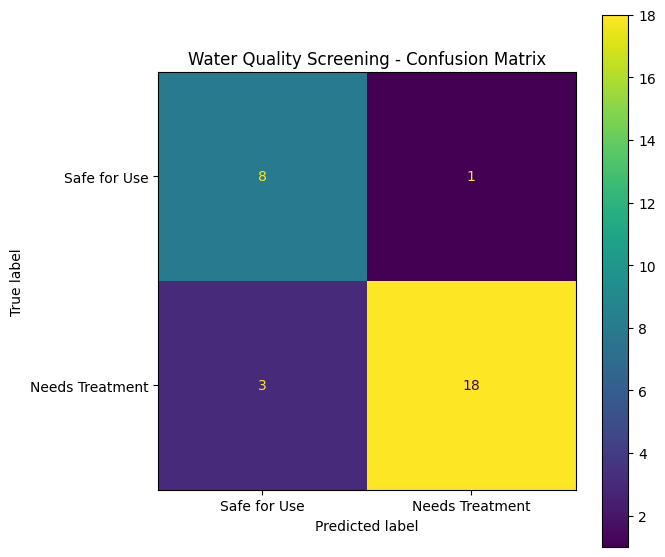

In [ ]:
# Cell 9 — Confusion matrix figure
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, values_format="d")
plt.title("Water Quality Screening - Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

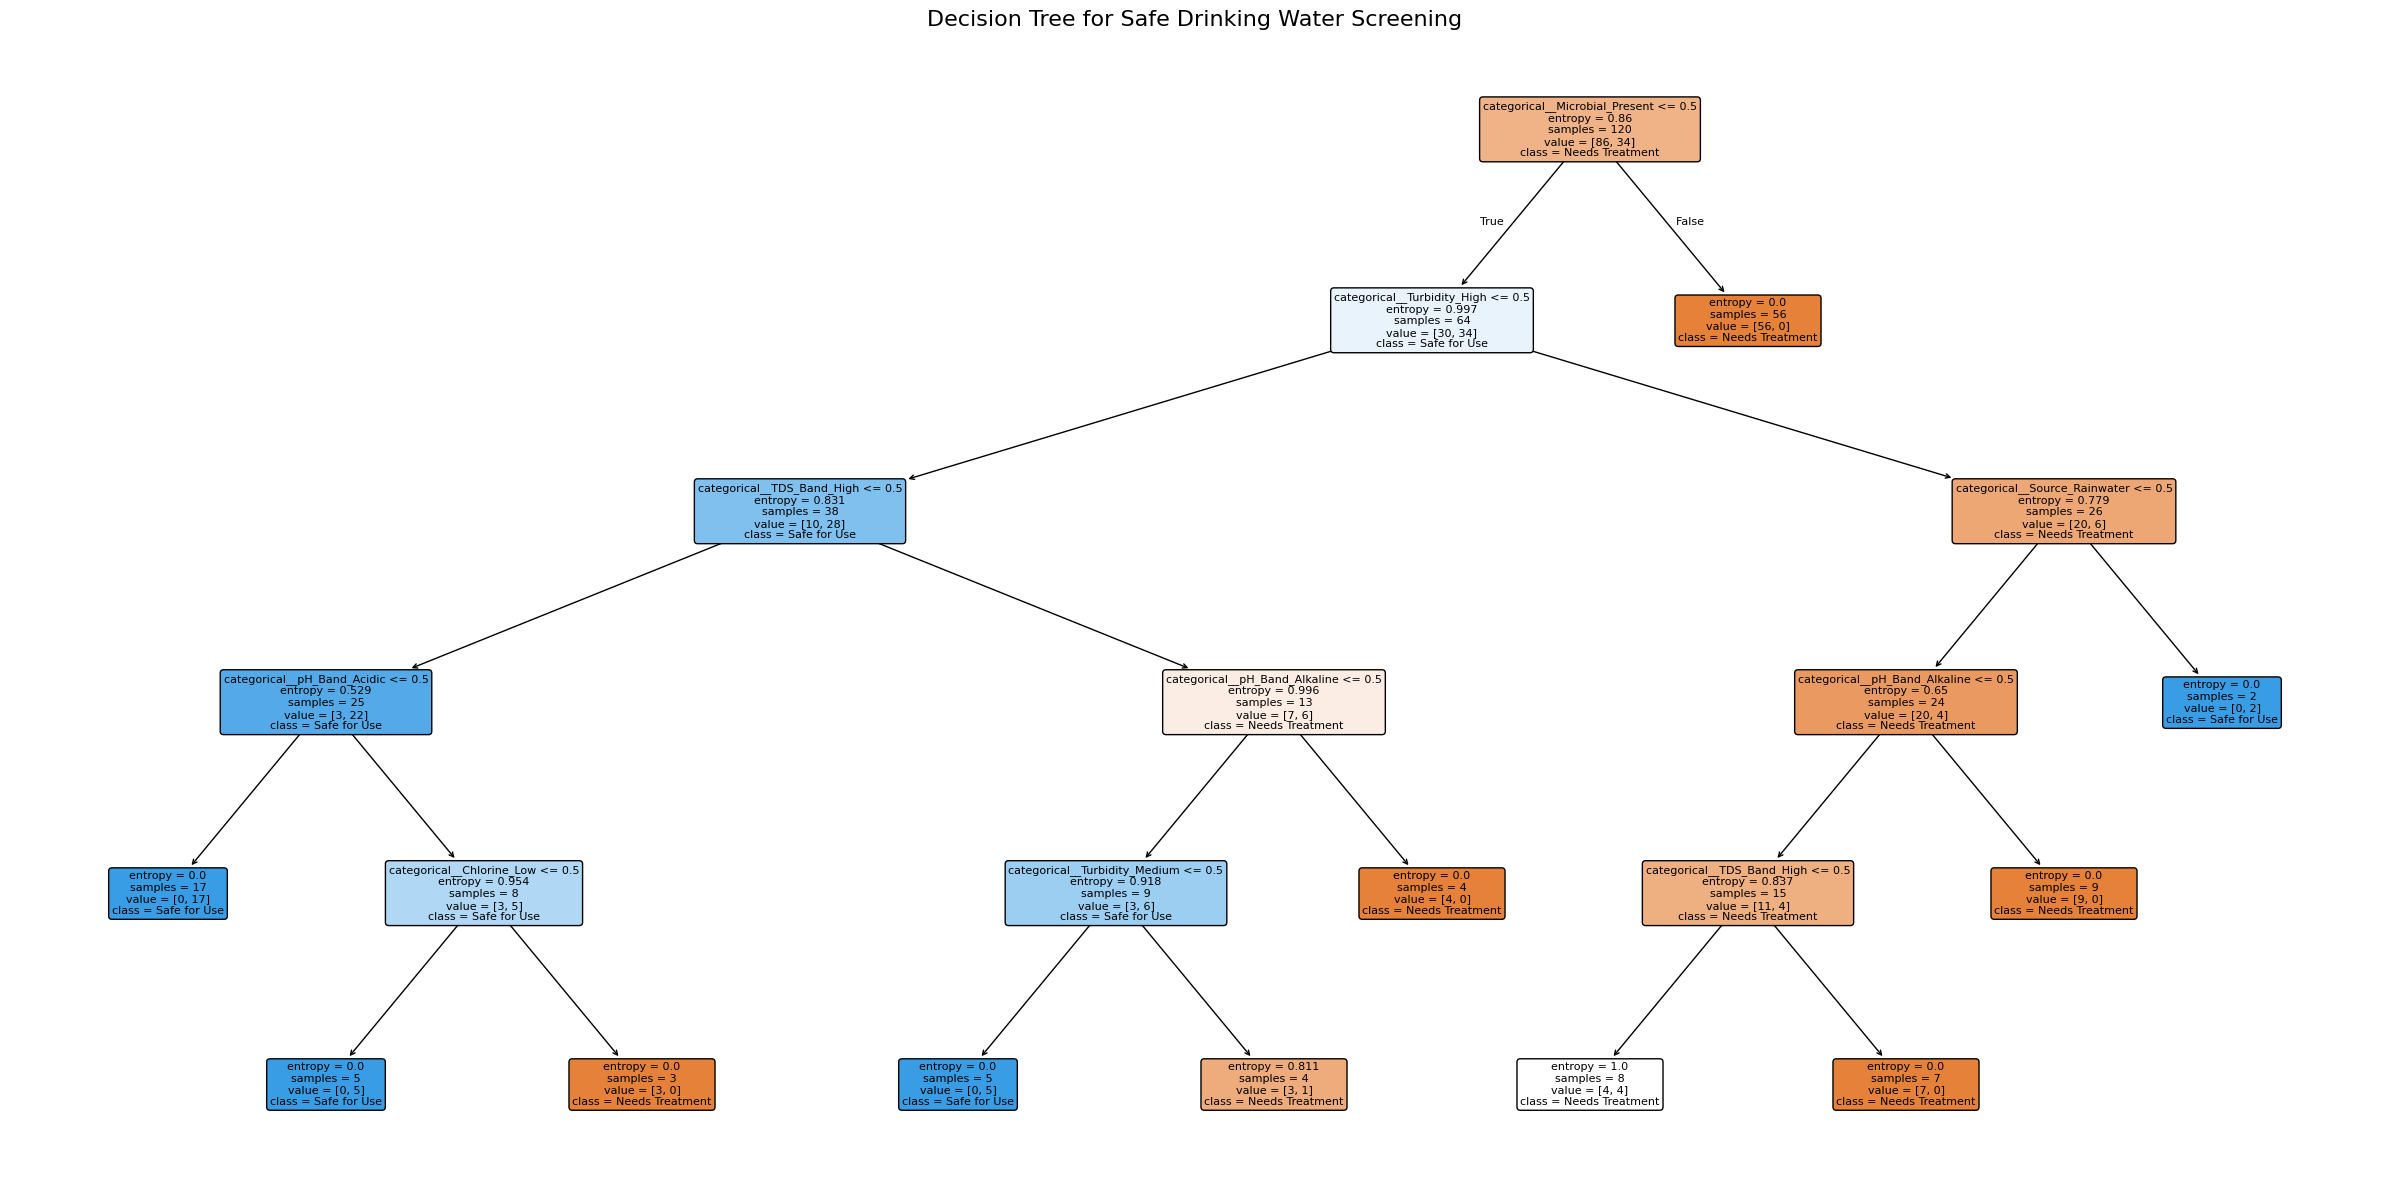

In [ ]:
# Cell 10 — Decision Tree visualization
tree_model = pipeline.named_steps["classifier"]
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(24, 12))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=tree_model.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree for Safe Drinking Water Screening", fontsize=16)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Cell 11 — Interpretable Decision Tree rules
rules = export_text(
    tree_model,
    feature_names=list(feature_names)
)

print(rules)

with open("decision_tree_rules.txt", "w") as f:
    f.write(rules)

print("\nSaved: decision_tree_rules.txt")

|--- categorical__Microbial_Present <= 0.50
|   |--- categorical__Turbidity_High <= 0.50
|   |   |--- categorical__TDS_Band_High <= 0.50
|   |   |   |--- categorical__pH_Band_Acidic <= 0.50
|   |   |   |   |--- class: Safe for Use
|   |   |   |--- categorical__pH_Band_Acidic >  0.50
|   |   |   |   |--- categorical__Chlorine_Low <= 0.50
|   |   |   |   |   |--- class: Safe for Use
|   |   |   |   |--- categorical__Chlorine_Low >  0.50
|   |   |   |   |   |--- class: Needs Treatment
|   |   |--- categorical__TDS_Band_High >  0.50
|   |   |   |--- categorical__pH_Band_Alkaline <= 0.50
|   |   |   |   |--- categorical__Turbidity_Medium <= 0.50
|   |   |   |   |   |--- class: Safe for Use
|   |   |   |   |--- categorical__Turbidity_Medium >  0.50
|   |   |   |   |   |--- class: Needs Treatment
|   |   |   |--- categorical__pH_Band_Alkaline >  0.50
|   |   |   |   |--- class: Needs Treatment
|   |--- categorical__Turbidity_High >  0.50
|   |   |--- categorical__Source_Rainwater <= 0.50
|   

In [ ]:
# Cell 12 — Five-sample comparison
comparison_samples = pd.DataFrame([
    ["Neutral", "Low", "Normal", "Adequate", "Absent", "Groundwater"],
    ["Neutral", "High", "Normal", "Adequate", "Absent", "Groundwater"],
    ["Neutral", "Low", "High", "Adequate", "Absent", "Surface"],
    ["Neutral", "Low", "Normal", "Low", "Absent", "Surface"],
    ["Neutral", "Low", "Normal", "Adequate", "Present", "Surface"]
], columns=attributes)

def concept_prediction(row):
    if (
        row["Turbidity"] == "Low"
        and row["TDS_Band"] == "Normal"
        and row["Chlorine"] == "Adequate"
        and row["Microbial"] == "Absent"
    ):
        return "Safe for Use"
    return "Needs Treatment"

comparison = comparison_samples.copy()
comparison["Concept Learning"] = comparison.apply(concept_prediction, axis=1)
comparison["Decision Tree"] = pipeline.predict(comparison_samples)
comparison["Match"] = comparison["Concept Learning"] == comparison["Decision Tree"]

display(comparison)

,pH_Band,Turbidity,TDS_Band,Chlorine,Microbial,Source,Concept Learning,Decision Tree,Match
0,Neutral,Low,Normal,Adequate,Absent,Groundwater,Safe for Use,Safe for Use,True
1,Neutral,High,Normal,Adequate,Absent,Groundwater,Needs Treatment,Needs Treatment,True
2,Neutral,Low,High,Adequate,Absent,Surface,Needs Treatment,Safe for Use,False
3,Neutral,Low,Normal,Low,Absent,Surface,Needs Treatment,Safe for Use,False
4,Neutral,Low,Normal,Adequate,Present,Surface,Needs Treatment,Needs Treatment,True


In [ ]:
# Cell 13 — Final summary
print("=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)
print("Dataset records:", len(df))
print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Decision Tree criterion: Entropy")
print("Maximum depth:", tree.max_depth)

print("\nMetrics")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1-score  : {f1*100:.2f}%")

print("\nConfusion Matrix:")
print(cm)

print("\nBest Information Gain attribute:", best_attribute)

print("\nFinal S:", S)
print("Final G:")
for g in G:
    print(g)

print("\nGenerated files:")
print("- water_quality_dataset.csv")
print("- confusion_matrix.png")
print("- decision_tree.png")
print("- decision_tree_rules.txt")

FINAL RESULTS SUMMARY
Dataset records: 150
Training records: 120
Testing records: 30
Decision Tree criterion: Entropy
Maximum depth: 5

Metrics
Accuracy  : 86.67%
Precision : 72.73%
Recall    : 88.89%
F1-score  : 80.00%

Confusion Matrix:
[[ 8  1]
 [ 3 18]]

Best Information Gain attribute: pH_Band

Final S: ['?', 'Low', 'Normal', '?', 'Absent', '?']
Final G:
['?', '?', '?', '?', '?', '?']

Generated files:
- water_quality_dataset.csv
- confusion_matrix.png
- decision_tree.png
- decision_tree_rules.txt
